# 02 — Exploratory Data Analysis (item 3)

## What EDA is for

EDA is not "make pretty charts." It's a structured interrogation of the dataset with four goals:

1. **Understand each feature on its own** — distributions, ranges, weirdness.
2. **Understand each feature's relationship with the target** — is it informative?
3. **Find data quality issues early** — outliers, encoding inconsistencies, suspicious values.
4. **Generate hypotheses for feature engineering** — what new features might help?

If you finish EDA without a written list of observations and a list of feature-engineering ideas, you didn't do EDA — you made charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_csv(Path('data') / 'telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# A binary numeric target makes plotting + correlations easier
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

# Identify column groups — useful throughout
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [
    c for c in df.columns
    if c not in numeric_cols + ['customerID', 'Churn', 'ChurnFlag']
]
len(categorical_cols), categorical_cols

Matplotlib is building the font cache; this may take a moment.


(16,
 ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

## 3.1 Univariate — numerical features

For each numeric column, look at:
- **Center + spread** (mean, std, quartiles) — does it look reasonable?
- **Shape** of the distribution — symmetric? skewed? multimodal? Skewed features often benefit from a log transform.
- **Outliers / impossible values** — negative tenure? zero charges with high tenure?

In [2]:
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


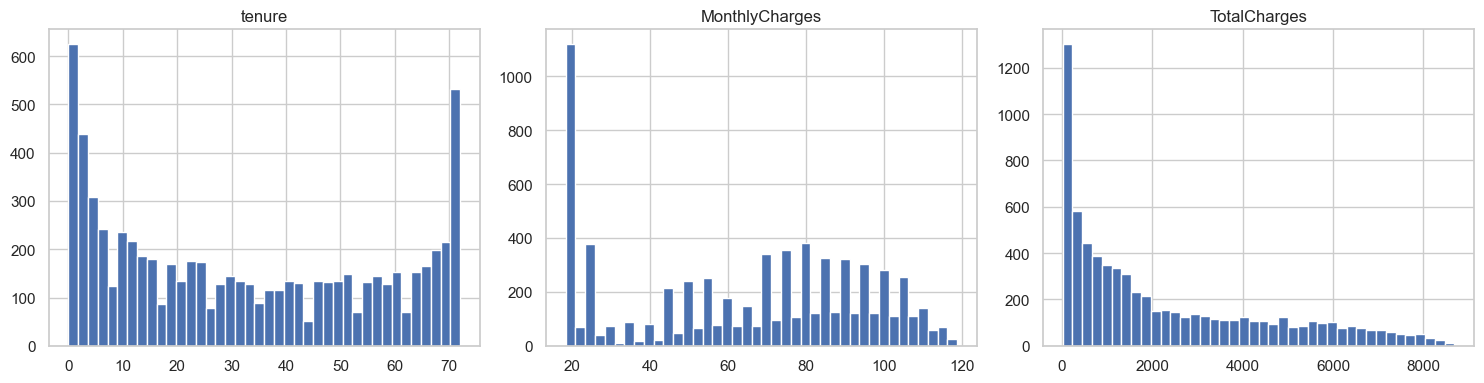

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    df[col].hist(bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observe and write down what you see.** Some prompts:

- `tenure` is bimodal — there's a big spike at month 1 and another at month 72. What does that mean about the customer base?
- `MonthlyCharges` is bimodal too, with a spike at the low end. Probably reflects basic vs. premium service tiers.
- `TotalCharges` is heavily right-skewed (tail of long-tenured high-spend customers). Could benefit from a log transform later.

Don't just nod — type your observations into a markdown cell below this one. The writing forces the noticing.

## 3.2 Univariate — categorical features

For each categorical column, look at:
- **Cardinality** — 2 levels? 3? 50? (50 means we need a different encoding strategy)
- **Imbalance within levels** — is one level 99% of the column? (probably useless)
- **Encoding consistency** — `Yes`/`No` vs `Yes`/`No internet service` is a trap to watch for

In [4]:
for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    print(f'{col} ({len(counts)} levels)')
    print(counts.to_string())
    print('-' * 40)

gender (2 levels)
gender
Male      3555
Female    3488
----------------------------------------
SeniorCitizen (2 levels)
SeniorCitizen
0    5901
1    1142
----------------------------------------
Partner (2 levels)
Partner
No     3641
Yes    3402
----------------------------------------
Dependents (2 levels)
Dependents
No     4933
Yes    2110
----------------------------------------
PhoneService (2 levels)
PhoneService
Yes    6361
No      682
----------------------------------------
MultipleLines (3 levels)
MultipleLines
No                  3390
Yes                 2971
No phone service     682
----------------------------------------
InternetService (3 levels)
InternetService
Fiber optic    3096
DSL            2421
No             1526
----------------------------------------
OnlineSecurity (3 levels)
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
----------------------------------------
OnlineBackup (3 levels)
OnlineBackup
No        

**Observe:** notice columns like `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, etc. They have **three** levels: `Yes`, `No`, and `No internet service`. That third level is just a redundant restatement of `InternetService == 'No'`. We'll collapse this in the cleaning step.

## 3.3 Bivariate — each feature vs. the target

This is where EDA earns its keep. For every feature, ask: **does the churn rate change across its values?** If yes, it's predictive. If no, it's noise.

### Numerical features split by target

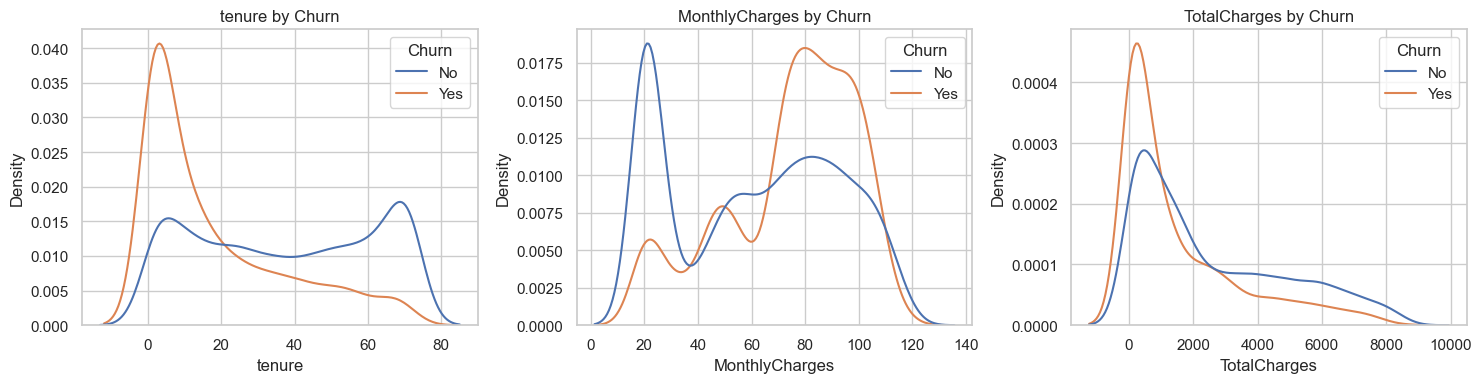

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', common_norm=False, ax=ax)
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

**Observe:**

- **`tenure`**: churners are concentrated at low tenure. The longer someone stays, the less likely they leave. This is a strong signal.
- **`MonthlyCharges`**: churners skew toward higher monthly charges. Premium customers churn more — counterintuitive at first, but makes sense if they're paying for services they don't value.
- **`TotalCharges`**: churners skew low (because they leave early, before accumulating big totals). This is partly redundant with tenure.

### Categorical features — churn rate per level

The right plot for this is a grouped bar of `% churn` per category level — not a stacked count, which hides the rate when categories are imbalanced.

In [6]:
def churn_rate_by(col):
    return df.groupby(col)['ChurnFlag'].agg(['mean', 'count']).rename(
        columns={'mean': 'churn_rate', 'count': 'n'}
    ).sort_values('churn_rate', ascending=False)

# Try a few high-signal ones
for col in ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']:
    print(col)
    print(churn_rate_by(col))
    print('-' * 40)

Contract
                churn_rate     n
Contract                        
Month-to-month    0.427097  3875
One year          0.112695  1473
Two year          0.028319  1695
----------------------------------------
InternetService
                 churn_rate     n
InternetService                  
Fiber optic        0.418928  3096
DSL                0.189591  2421
No                 0.074050  1526
----------------------------------------
PaymentMethod
                           churn_rate     n
PaymentMethod                              
Electronic check             0.452854  2365
Mailed check                 0.191067  1612
Bank transfer (automatic)    0.167098  1544
Credit card (automatic)      0.152431  1522
----------------------------------------
TechSupport
                     churn_rate     n
TechSupport                          
No                     0.416355  3473
Yes                    0.151663  2044
No internet service    0.074050  1526
-------------------------------------

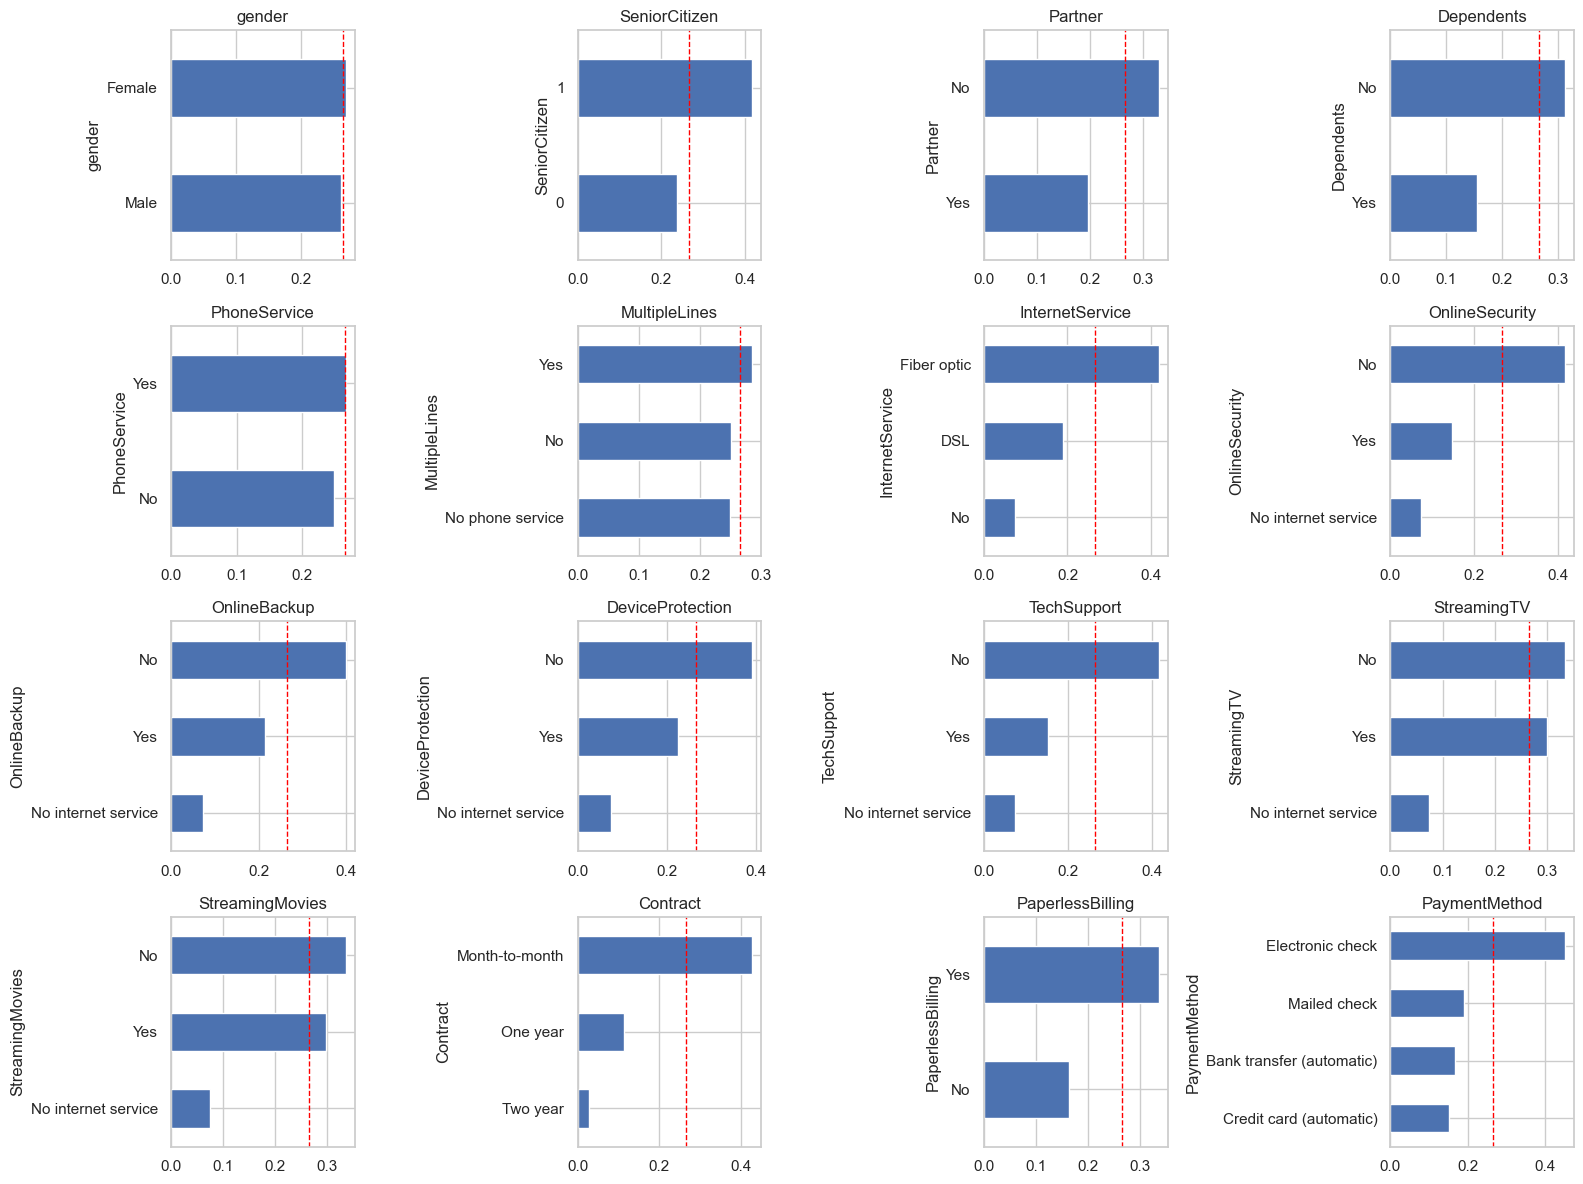

In [7]:
# Plot all categorical features in one grid
n = len(categorical_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
overall = df['ChurnFlag'].mean()

for ax, col in zip(axes.flat, categorical_cols):
    rates = df.groupby(col)['ChurnFlag'].mean().sort_values()
    rates.plot(kind='barh', ax=ax)
    ax.axvline(overall, color='red', linestyle='--', linewidth=1)
    ax.set_title(col)
    ax.set_xlabel('')

for ax in axes.flat[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Observe.** The red dashed line is the overall churn rate (~27%). Features where the bars span a wide range across that line are highly predictive. Features where all bars sit near the line are uninformative.

Write down which features look strongest and which look like noise — you'll use this list when feature-engineering.

## 3.4 Correlations among numeric features

Goal: spot **redundant** features (highly correlated with each other) and **leakage** (a feature correlated with the target in a way that wouldn't be available at prediction time).

In [ ]:
corr = df[numeric_cols + ['ChurnFlag']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
plt.show()

**Observe:**

- `tenure` and `TotalCharges` are almost the same thing (correlation ~0.83). Total = MonthlyCharges × tenure, roughly. If we include both naively, a linear model gets confused. Decision for cleaning: probably keep `tenure` and drop or transform `TotalCharges`.
- `tenure` has a strong **negative** correlation with `ChurnFlag` — long-tenured customers churn less. Consistent with the KDE plot above.

**Leakage check.** Look at every feature and ask: "would this value be known *at the moment we're making the prediction*?" In this dataset, none of the columns are obviously leaky — they all describe account state, not future behavior. Good.

## 3.5 EDA wrap-up — your turn

Fill in this markdown cell with your own findings. The act of writing them down is the deliverable of EDA.

### Observations
- _e.g._ Month-to-month contracts churn at ~43%; two-year contracts at ~3%. Contract is probably the single strongest predictor.
- _(add yours)_

### Data quality issues to fix in the next notebook
- `TotalCharges` has 11 NaNs from tenure=0 customers — decide: drop, impute with 0, or impute with median.
- `No internet service` is a redundant third level in 6 columns — collapse to `No`.
- `SeniorCitizen` is 0/1 numeric while other binaries are Yes/No strings — normalize.
- _(add yours)_

### Feature-engineering hypotheses
- _e.g._ `num_services` = count of `Yes` across the 6 add-on service columns.
- _e.g._ `charges_per_tenure_month` = `TotalCharges / max(tenure, 1)` (sanity-check: should be ≈ `MonthlyCharges`).
- _e.g._ Bin `tenure` into early/mid/late life-stage buckets.
- _(add yours)_

When you've filled this out, ping me and we'll move to notebook 03 (cleaning + feature engineering).